# Census Income Prediction
Classification Model

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='darkgrid')

In [3]:
df=pd.read_csv('census-income.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14                   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Exploratory Data Analysis

In [4]:
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' '],
      dtype='object')

In [5]:
df.columns=['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'Income']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
for i in df.columns:
    print(df[i].unique())

[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
[ 77516  83311 215646 ...  34066  84661 257302]
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Pr

In [8]:
(df==' ?').sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
Income               0
dtype: int64

In [9]:
df.replace(' ?',np.nan,inplace=True)
(df==' ?').sum().sum()

np.int64(0)

# Data cleaning
#### 1.Remove null values
#### 2.Remove duplicates
#### 3.remove outliers

In [10]:
#1. null values
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
Income               0
dtype: int64

In [11]:
null_count=df.isnull().sum().sum()
null_value_percentage=(null_count/len(df))*100
print(null_value_percentage)

13.08927858481005


In [12]:
#null_percent is less than 15 remove it
df.dropna(inplace=True)
df.isnull().sum().sum()

np.int64(0)

In [13]:
#2. Duplicates
df.duplicated().sum()

np.int64(23)

In [14]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

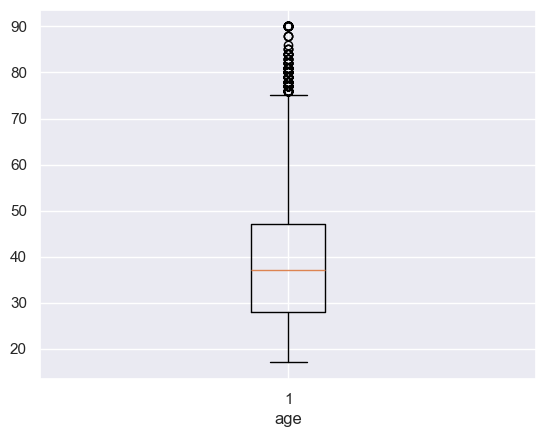

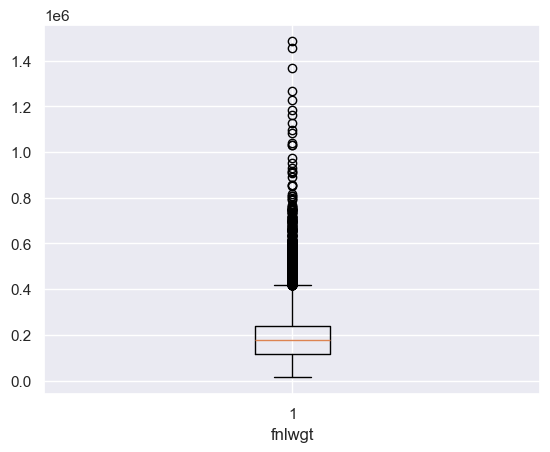

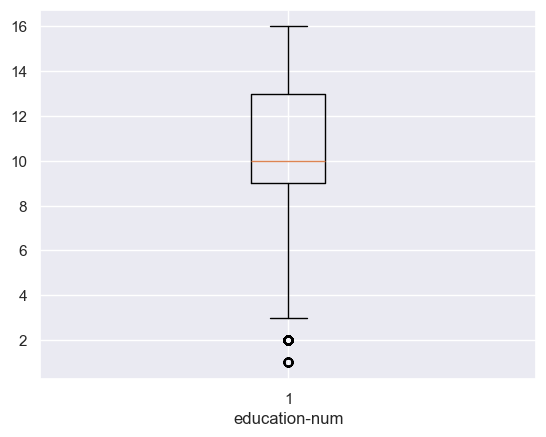

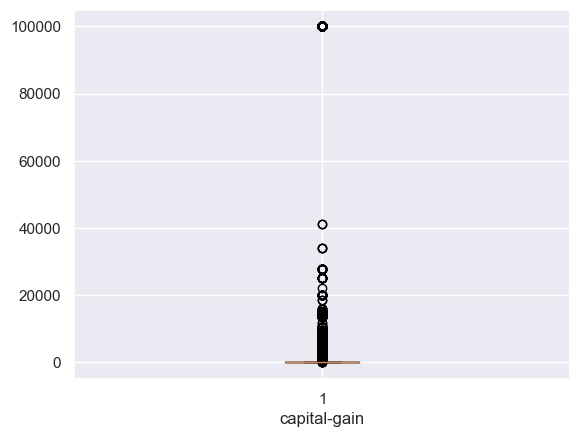

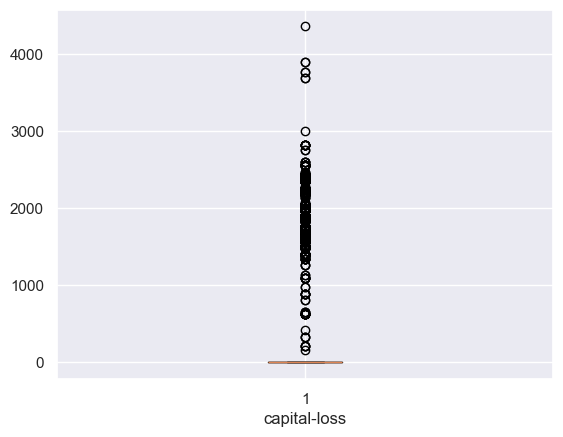

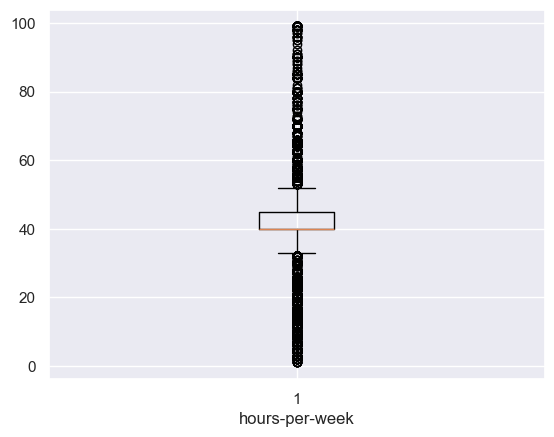

In [15]:
#3.Outliers
for i in df.columns:
    if df[i].dtype!='object':
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

Census data naturally contains extreme values.
So we do not remove them becuase they are important for our analysis.

# Visualisations 

## 1. Income Distributions

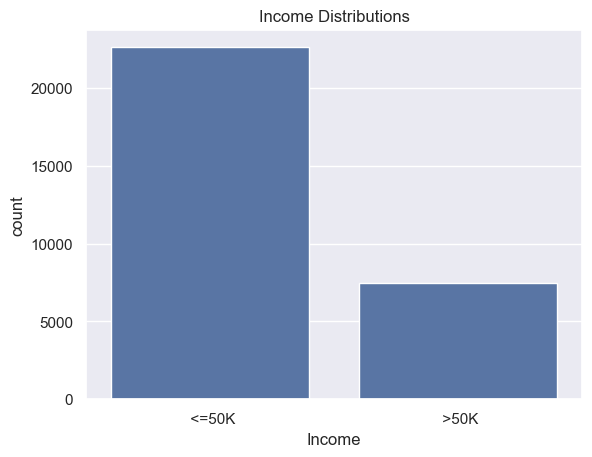

In [16]:
sns.countplot(x=df['Income'])
plt.title('Income Distributions')
plt.show()

## Insight:
This shows dataset is imbalanced

### 2.Age vs Income

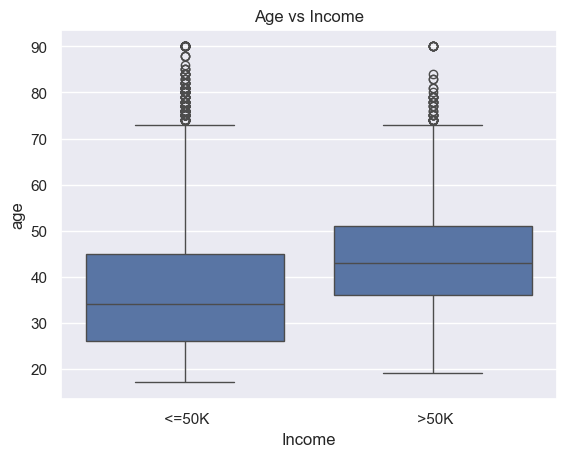

In [17]:
sns.boxplot(x=df['Income'],y=df['age'])
plt.title('Age vs Income')
plt.show()

## Insights:

People earning >50K are generally older.
This suggest that work experience is a major factor influencing income.

# 3. Education vs Income

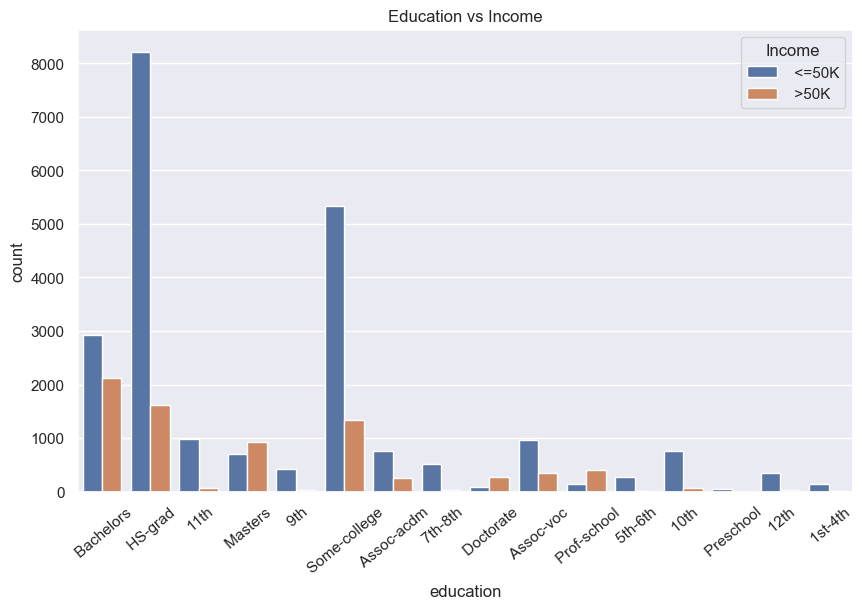

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['education'],hue=df['Income'])
plt.title('Education vs Income')
plt.xticks(rotation=40)
plt.show()

# **Insights:**

Higher Education levels(Masters,Doctrate,Prof-school) have more people earning >50k.
Eduaction is one of the strongest predictors of income.

## Encodeing

In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for i in df.columns:
    if df[i].dtypes=='object':
        df[i]=le.fit_transform(df[i])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30139 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30139 non-null  int64
 1   workclass       30139 non-null  int64
 2   fnlwgt          30139 non-null  int64
 3   education       30139 non-null  int64
 4   education-num   30139 non-null  int64
 5   marital-status  30139 non-null  int64
 6   occupation      30139 non-null  int64
 7   relationship    30139 non-null  int64
 8   race            30139 non-null  int64
 9   sex             30139 non-null  int64
 10  capital-gain    30139 non-null  int64
 11  capital-loss    30139 non-null  int64
 12  hours-per-week  30139 non-null  int64
 13  native-country  30139 non-null  int64
 14  Income          30139 non-null  int64
dtypes: int64(15)
memory usage: 3.7 MB


One-Hot Encoding could also be used, tree-based models like Decision Trees and Random Forests are not affected by ordinal relationships, 
so Label Encoding works well for this classification task.

# Model Building 

In [20]:
x=df.drop('Income',axis=1)
y=df['Income']

In [21]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.metrics import *

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
y_train.value_counts()

Income
0    18148
1     5963
Name: count, dtype: int64

# Balancing the Dataset


In [23]:
sm=SMOTE(random_state=42)
x_train_balnced,y_train_balanced=sm.fit_resample(x_train,y_train)
y_train_balanced.value_counts()

Income
0    18148
1    18148
Name: count, dtype: int64

## Removing Noisy Data 

In [24]:
enn = EditedNearestNeighbours()
x_clean, y_clean = enn.fit_resample(x_train_balnced,y_train_balanced)
y_clean.value_counts()

Income
0    18148
1     9928
Name: count, dtype: int64

# 1.Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

x_clean_lr = scaler.fit_transform(x_clean)
x_test_lr = scaler.transform(x_test)
lr=LogisticRegression(max_iter=500)
lr.fit(x_clean_lr,y_clean)

LogisticRegression(max_iter=500)

In [27]:
lr_pred=lr.predict(x_test_lr)
lr_acc=accuracy_score(y_test,lr_pred)
round((lr_acc*100),3)

81.304

In [46]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4485
           1       0.67      0.53      0.59      1543

    accuracy                           0.81      6028
   macro avg       0.76      0.72      0.74      6028
weighted avg       0.80      0.81      0.81      6028



# 2.Decision Tree

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV

## Hyper Parameter Turing

In [30]:
dt_model=DecisionTreeClassifier()
grid_parameters={
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 4, 8]
}

In [31]:
grid_model=GridSearchCV(dt_model,grid_parameters,cv=3)
grid_model.fit(x_clean,y_clean)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30, None],
                         'min_samples_leaf': [1, 4, 8],
                         'min_samples_split': [2, 10, 50]})

In [32]:
best_model=grid_model.best_estimator_
grid_model.best_params_

{'criterion': 'entropy',
 'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 50}

In [33]:
dt_pred=best_model.predict(x_test)
dt_acc=accuracy_score(y_test,dt_pred)
round((dt_acc*100),3)

83.543

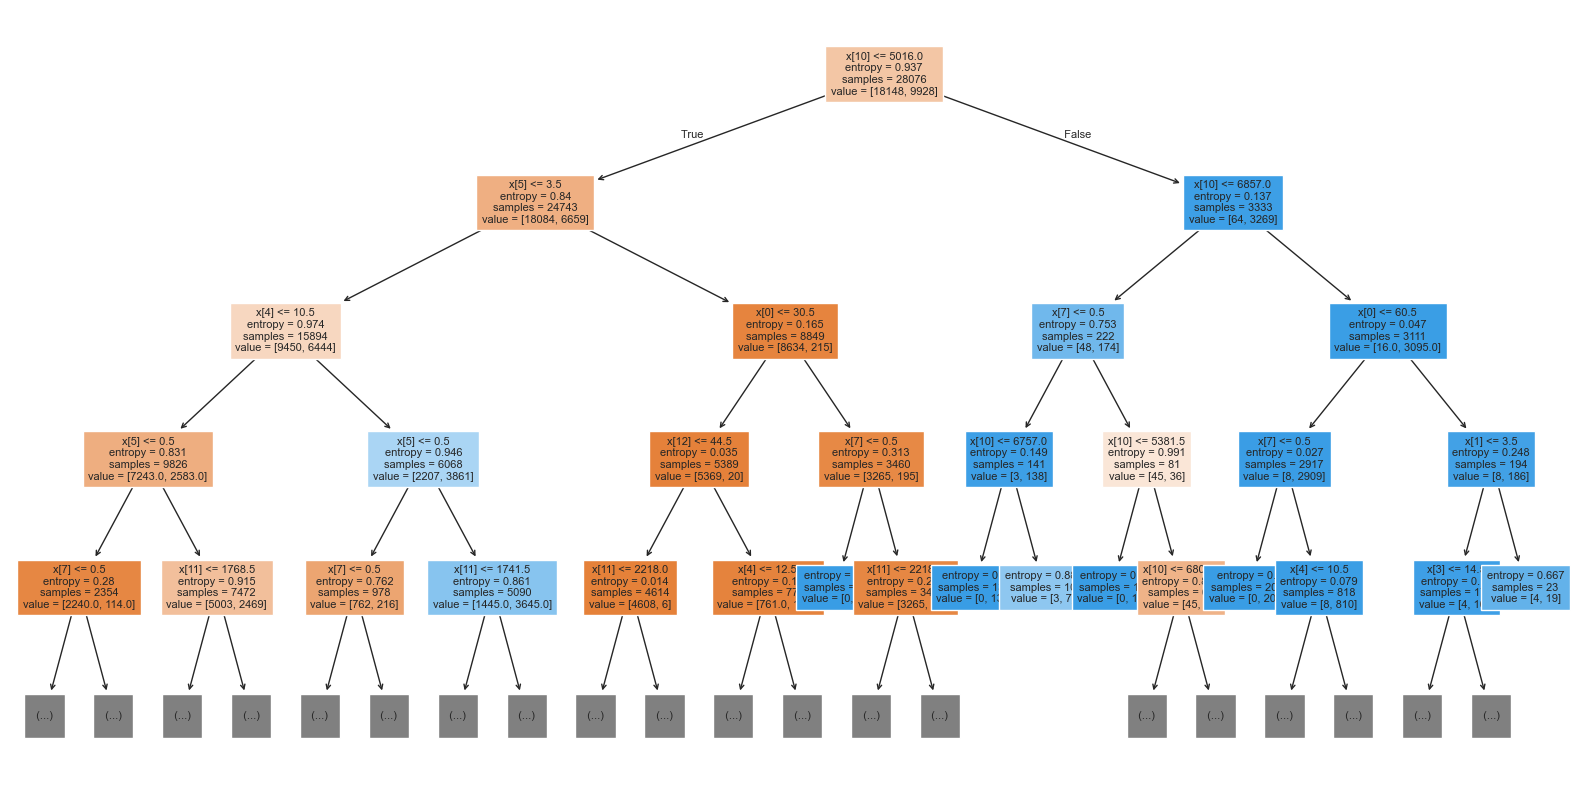

In [34]:
plt.figure(figsize=(20,10))
tree.plot_tree(best_model,max_depth=4, fontsize=8, filled=True)
plt.show()

In [47]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4485
           1       0.75      0.53      0.62      1543

    accuracy                           0.84      6028
   macro avg       0.80      0.74      0.76      6028
weighted avg       0.83      0.84      0.83      6028



# Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
rf=RandomForestClassifier()

grid_params = {
    'n_estimators': [200, 300],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}


In [38]:
rf_model=GridSearchCV(rf,grid_params,n_jobs=-1,scoring='accuracy')
rf_model.fit(x_clean,y_clean)

GridSearchCV(estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [20, 30, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [200, 300]},
             scoring='accuracy')

In [39]:
rf_best_model=rf_model.best_estimator_
rf_model.best_params_

{'criterion': 'gini',
 'max_depth': 30,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [41]:
rf_pred=rf_best_model.predict(x_test)
rf_acc=accuracy_score(y_test,rf_pred)
round((rf_acc*100),3)

84.323

In [43]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90      4485
           1       0.82      0.50      0.62      1543

    accuracy                           0.84      6028
   macro avg       0.83      0.73      0.76      6028
weighted avg       0.84      0.84      0.83      6028



# Accuracy Comaprision


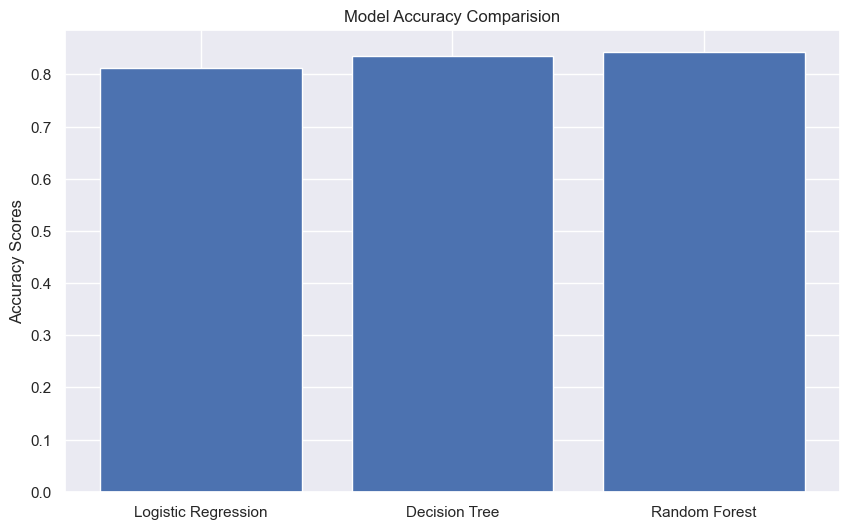

In [45]:
model_names=['Logistic Regression','Decision Tree','Random Forest']
accuracy_scores=[lr_acc,dt_acc,rf_acc]

plt.figure(figsize=(10,6))
plt.bar(model_names,accuracy_scores)
plt.title('Model Accuracy Comparision')
plt.ylabel('Accuracy Scores')
plt.show()